```
┌───────────────────────────────────────────────────────────────────────┐
│ Projeto Avaliativo Final - Módulo 1                                   │
│ Aluno: Luiz Felipe F. V. Vieira                                       │
└───────────────────────────────────────────────────────────────────────┘

┌───────────────────────────────────────────────────────────────────────┐
│ Fluxo do Pipeline de dados:                                           │
│                                                                       │
│ 1- EXTRACT - Verificação e conhecimento da base                       │
│                                                                       │
│ 2- TRANSFORM - Limpeza dos dados (DUPLICADOS)                         │
│                                                                       │
│ 3- TRANSFORM - Correção e tratamento dos dados                        │
│   3.1 -> Correção de tipos (str > datetime)                           │
│   3.2 -> Conversão e otimização dos tipos de dados                    │
│   3.3 -> Inconsistência de dados                                      │
│       3.3.1 -> DataFrame Cargos e Departamentos                       │
│       3.3.2 -> DataFrame Localização                                  │
│       3.3.3 -> Coluna COMISSAO                                        │
│   3.4 -> Engenharia de Features                                       │
│                                                                       │
│ 4. LOAD - Gerar nova base limpa                                       │
│   -> Salvar em um arquivo CSV                                         │
│   -> Garantir que a AED seja feita na base limpa                      │
│                                                                       │
│ 5- AED - Gerar estatísticas e análises                                │
│   5.1 -> Estatísticas para coluna SALÁRIO:                            │
│       (média; mediana; desvio padrão; moda; máximo; mínimo;contagem)  │
│   5.2 -> Salários por departamento e cargo                            │
│   5.3 -> Funcionários por região (CIDADE)                             │
│   5.4 -> Salários por região (CIDADE)                                 │
│   5.5 -> Ano / Mês com maiores contratações                           │
│   5.6 -> Tempo de casa vs Salário para um mesmo Departamento          │
│                                                                       │
├───────────────────────────────────────────────────────────────────────┤
│                                                                       │
│ Para fins didáticos, foram mantidos todos os testes e avaliações,     │
│ mesmo que não resultasse em transformação na base de dados.           │
│                                                                       │
└───────────────────────────────────────────────────────────────────────┘
```

---

In [589]:

# IMPORTS & CONFIGURAÇÂO

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Leitura do CSV baixado do freeSQL
arquivo_1 = "query_01.csv"
arquivo_2 = "query_02.csv"

df_cargos_depto = pd.read_csv(arquivo_1)
df_localizacao = pd.read_csv(arquivo_2)

print('Bibliotecas e arquivos .csv importados.')

Bibliotecas e arquivos .csv importados.


---

```
┌───────────────────────────────────────────────────────────────────────┐
│ 1- EXTRACT - Verificação e conhecimento da base                       │
│   -> df.head(3) / df.tail(3)                                          │
│   -> df.info()                                                        │
│   -> df.isnull().sum()                                                │
│   -> df.nunique()                                                     │
└───────────────────────────────────────────────────────────────────────┘
```

```
┌───────────────────────────────────────────────────────────────────────┐
│ DataFrame Cargos e Departamentos                                      │
└───────────────────────────────────────────────────────────────────────┘
```

In [590]:
print('Exibindo as primeiras 3 linhas do DataFrame Cargos e Departamentos.')
df_cargos_depto.head(3)



Exibindo as primeiras 3 linhas do DataFrame Cargos e Departamentos.


,ID,DATA_CONTRATACAO,SALARIO,COMISSAO,DEPARTAMENTO,CARGO,CARGO_SALARIO_MIN,CARGO_SALARIO_MAX
0,100,2013-06-17T00:00:00Z,24000,NaN,Executive,President,20080,40000
1,101,2015-09-21T00:00:00Z,17000,NaN,Executive,Administration Vice President,15000,30000
2,102,2011-01-13T00:00:00Z,17000,NaN,Executive,Administration Vice President,15000,30000


In [591]:
print('Exibindo as Últimas 3 linhas do DataFrame Cargos e Departamentos.')
df_cargos_depto.tail(3)



Exibindo as Últimas 3 linhas do DataFrame Cargos e Departamentos.


,ID,DATA_CONTRATACAO,SALARIO,COMISSAO,DEPARTAMENTO,CARGO,CARGO_SALARIO_MIN,CARGO_SALARIO_MAX
104,204,2012-06-07T00:00:00Z,10000,NaN,Public Relations,Public Relations Representative,4500,10500
105,205,2012-06-07T00:00:00Z,12008,NaN,Accounting,Accounting Manager,8200,16000
106,206,2012-06-07T00:00:00Z,8300,NaN,Accounting,Public Accountant,4200,9000


In [592]:
print('Exibindo número de registros, colunas, valores não nulos e tipo de dados.')
df_cargos_depto.info()



Exibindo número de registros, colunas, valores não nulos e tipo de dados.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 107 non-null    int64  
 1   DATA_CONTRATACAO   107 non-null    object 
 2   SALARIO            107 non-null    int64  
 3   COMISSAO           35 non-null     float64
 4   DEPARTAMENTO       106 non-null    object 
 5   CARGO              107 non-null    object 
 6   CARGO_SALARIO_MIN  107 non-null    int64  
 7   CARGO_SALARIO_MAX  107 non-null    int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 6.8+ KB


In [593]:
print('Exibindo número de registros nulos em cada coluna.')
df_cargos_depto.isnull().sum()     



Exibindo número de registros nulos em cada coluna.


ID                    0
DATA_CONTRATACAO      0
SALARIO               0
COMISSAO             72
DEPARTAMENTO          1
CARGO                 0
CARGO_SALARIO_MIN     0
CARGO_SALARIO_MAX     0
dtype: int64

In [594]:
print('Contando o número de registros únicos em cada coluna')
df_cargos_depto.nunique()



Contando o número de registros únicos em cada coluna


ID                   107
DATA_CONTRATACAO      98
SALARIO               58
COMISSAO               7
DEPARTAMENTO          11
CARGO                 19
CARGO_SALARIO_MIN     14
CARGO_SALARIO_MAX     13
dtype: int64

```
┌───────────────────────────────────────────────────────────────────────┐
│ DataFrame Localização (Distribuição Geográfica)                       │
└───────────────────────────────────────────────────────────────────────┘
```

In [595]:
print('Exibindo as primeiras 3 linhas do DataFrame Localização.')
df_localizacao.head(3)



Exibindo as primeiras 3 linhas do DataFrame Localização.


,ID,DATA_CONTRATACAO,SALARIO,COMISSAO,DEPARTAMENTO,CIDADE,ESTADO,PAIS,REGIAO
0,202,2015-08-17T00:00:00Z,6000,NaN,Marketing,Toronto,Ontario,Canada,Americas
1,201,2014-02-17T00:00:00Z,13000,NaN,Marketing,Toronto,Ontario,Canada,Americas
2,205,2012-06-07T00:00:00Z,12008,NaN,Accounting,Seattle,Washington,United States of America,Americas


In [596]:
print('Exibindo as Últimas 3 linhas do DataFrame Localicação.')
df_localizacao.tail(3)



Exibindo as Últimas 3 linhas do DataFrame Localicação.


,ID,DATA_CONTRATACAO,SALARIO,COMISSAO,DEPARTAMENTO,CIDADE,ESTADO,PAIS,REGIAO
104,146,2015-01-05T00:00:00Z,13500,0.30,Sales,Oxford,Oxford,United Kingdom of Great Britain and Northern I...,Europe
105,145,2014-10-01T00:00:00Z,14000,0.40,Sales,Oxford,Oxford,United Kingdom of Great Britain and Northern I...,Europe
106,178,2017-05-24T00:00:00Z,7000,0.15,NaN,NaN,NaN,NaN,NaN


In [597]:
print('Exibindo número de registros, colunas, valores não nulos e tipo de dados.')
df_localizacao.info()



Exibindo número de registros, colunas, valores não nulos e tipo de dados.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                107 non-null    int64  
 1   DATA_CONTRATACAO  107 non-null    object 
 2   SALARIO           107 non-null    int64  
 3   COMISSAO          35 non-null     float64
 4   DEPARTAMENTO      106 non-null    object 
 5   CIDADE            106 non-null    object 
 6   ESTADO            105 non-null    object 
 7   PAIS              106 non-null    object 
 8   REGIAO            106 non-null    object 
dtypes: float64(1), int64(2), object(6)
memory usage: 7.7+ KB


In [598]:
print('Exibindo número de registros nulos em cada coluna.')
df_localizacao.isnull().sum()   



Exibindo número de registros nulos em cada coluna.


ID                   0
DATA_CONTRATACAO     0
SALARIO              0
COMISSAO            72
DEPARTAMENTO         1
CIDADE               1
ESTADO               2
PAIS                 1
REGIAO               1
dtype: int64

In [599]:
print('Contando o número de registros únicos em cada coluna')
df_localizacao.nunique()



Contando o número de registros únicos em cada coluna


ID                  107
DATA_CONTRATACAO     98
SALARIO              58
COMISSAO              7
DEPARTAMENTO         11
CIDADE                7
ESTADO                6
PAIS                  4
REGIAO                2
dtype: int64

---

```
┌───────────────────────────────────────────────────────────────────────┐
│ 2- TRANSFORM -  Limpeza dos dados [DUPLICADOS]                        │
└───────────────────────────────────────────────────────────────────────┘
```

In [600]:
#############################################################
# DataFrame Cargos e Departamentos
# Exibindo total linhas, únicas e duplicadas
# Objetivo: mostrar quantos registros seriam perdidos 
# ao aplicar drop_duplicates().
#############################################################

total_linhas = len(df_cargos_depto)
linhas_unicas = len(df_cargos_depto.drop_duplicates())
duplicadas = total_linhas - linhas_unicas

print('Mostrando o impacto da remoção dos duplicados no DF Cargos e Departamentos:')    
print(f'Total de linhas: {total_linhas:,}')
print(f'Linhas únicas: {linhas_unicas:,}')
print(f'Linhas duplicadas: {duplicadas:,}')
print(f'Percentual removido: {(duplicadas/total_linhas)*100:.2f}%')

Mostrando o impacto da remoção dos duplicados no DF Cargos e Departamentos:
Total de linhas: 107
Linhas únicas: 107
Linhas duplicadas: 0
Percentual removido: 0.00%


In [601]:
#############################################################
# DataFrame Localização
# Exibindo total linhas, únicas e duplicadas
# Objetivo: mostrar quantos registros seriam perdidos 
# ao aplicar drop_duplicates().
#############################################################

total_linhas = len(df_localizacao)
linhas_unicas = len(df_localizacao.drop_duplicates())
duplicadas = total_linhas - linhas_unicas

print('Mostrando o impacto da remoção dos duplicados no DF Localização:')    
print(f'Total de linhas: {total_linhas:,}')
print(f'Linhas únicas: {linhas_unicas:,}')
print(f'Linhas duplicadas: {duplicadas:,}')
print(f'Percentual removido: {(duplicadas/total_linhas)*100:.2f}%')

Mostrando o impacto da remoção dos duplicados no DF Localização:
Total de linhas: 107
Linhas únicas: 107
Linhas duplicadas: 0
Percentual removido: 0.00%




**CONCLUSÃO:**

-> Não existem linhas duplicadas em nenhum dos dataframes


---
```
┌───────────────────────────────────────────────────────────────────────┐
│ 3- TRANSFORM - Correção e tratamento dos dados                        │
│   3.1 -> Correção de tipos (str > datetime)                           │
│   3.2 -> Conversão e otimização dos tipos de dados                    │
│   3.3 -> Inconsistência de dados                                      │
│       3.3.1 -> DataFrame Cargos e Departamentos                       │
│       3.3.2 -> DataFrame Localização                                  │
│       3.3.3 -> Coluna COMISSAO                                        │
│   3.4 -> Engenharia de Features                                       │
└───────────────────────────────────────────────────────────────────────┘
```

```
┌───────────────────────────────────────────────────────────────────────┐
│   -> Fazer uma cópia dos DataFrames para preservar o original         │
│   e iniciar a transformação dos dados                                 │
└───────────────────────────────────────────────────────────────────────┘
```

In [602]:
df_depto_limpo = df_cargos_depto.copy()
df_localizacao_limpo = df_localizacao.copy()


```
┌───────────────────────────────────────────────────────────────────────┐
│   3.1 -> Correção de tipos (str > datetime)                           │
└───────────────────────────────────────────────────────────────────────┘
```

In [603]:
#############################################################    
# Converter coluna DATA_CONTRATACAO (str) para datetime
#############################################################    

df_depto_limpo['DATA_CONTRATACAO'] = pd.to_datetime(df_depto_limpo['DATA_CONTRATACAO'], errors='coerce')

print('===== DataFrame Cargos e Departamentos =====')
print('Coluna DATA_CONTRATACAO transformada no tipo datetime com sucesso!')
print(f'Novo tipo de dado da coluna DATA_CONTRATACAO: {df_depto_limpo['DATA_CONTRATACAO'].dtype}')

df_localizacao_limpo['DATA_CONTRATACAO'] = pd.to_datetime(df_localizacao_limpo['DATA_CONTRATACAO'], errors='coerce')

print('\n\n===== DataFrame Localização =====')
print('Coluna DATA_CONTRATACAO transformada no tipo datetime com sucesso!')
print(f'Novo tipo de dado da coluna DATA_CONTRATACAO: {df_localizacao_limpo['DATA_CONTRATACAO'].dtype}')


===== DataFrame Cargos e Departamentos =====
Coluna DATA_CONTRATACAO transformada no tipo datetime com sucesso!
Novo tipo de dado da coluna DATA_CONTRATACAO: datetime64[ns, UTC]


===== DataFrame Localização =====
Coluna DATA_CONTRATACAO transformada no tipo datetime com sucesso!
Novo tipo de dado da coluna DATA_CONTRATACAO: datetime64[ns, UTC]


In [604]:
#############################################################    
# Inconsistência de dados -> Data: Válida ou NaT?
# Objetivo: Validar coluna de Data
#############################################################    

datas_invalidas = df_depto_limpo['DATA_CONTRATACAO'].isna().sum()
print(f'Linhas com Datas inválidas (DataFrame Cargos Departamentos): {datas_invalidas}')


datas_invalidas = df_localizacao_limpo['DATA_CONTRATACAO'].isna().sum()
print(f'Linhas com Datas inválidas (DataFrame Localização): {datas_invalidas}')



Linhas com Datas inválidas (DataFrame Cargos Departamentos): 0
Linhas com Datas inválidas (DataFrame Localização): 0


```
┌───────────────────────────────────────────────────────────────────────┐
│   3.2 -> Conversão e otimização dos tipos de dados                    │
└───────────────────────────────────────────────────────────────────────┘
```

Realizar a adequação dos tipos de dados das colunas visando reduzir o consumo de memória e melhorar a eficiência das operações analíticas.

Colunas categóricas -> Converter de str para o tipo category

Colunas numéricas -> Ajustar para tipo mais compacto (int16 e int32)

In [605]:
#############################################################    
# Conversão de dados:
# Tabela df_depto_limpo (Cargos e Departamentos)
# Após análise dos dados no item 1 (conhecimento da base)
#############################################################    


# Conversão das colunas para os novos tipos
df_depto_limpo['ID'] = df_depto_limpo['ID'].astype('int16')
df_depto_limpo['SALARIO'] = df_depto_limpo['SALARIO'].astype('int32')
df_depto_limpo['DEPARTAMENTO'] = df_depto_limpo['DEPARTAMENTO'].astype('category')
df_depto_limpo['CARGO'] = df_depto_limpo['CARGO'].astype('category')
df_depto_limpo['CARGO_SALARIO_MIN'] = df_depto_limpo['CARGO_SALARIO_MIN'].astype('int32')
df_depto_limpo['CARGO_SALARIO_MAX'] = df_depto_limpo['CARGO_SALARIO_MAX'].astype('int32')

print('Mostrando o nome da coluna e seu respectivo tipo de dado transformado:')
print(df_depto_limpo.dtypes)   


Mostrando o nome da coluna e seu respectivo tipo de dado transformado:
ID                                 int16
DATA_CONTRATACAO     datetime64[ns, UTC]
SALARIO                            int32
COMISSAO                         float64
DEPARTAMENTO                    category
CARGO                           category
CARGO_SALARIO_MIN                  int32
CARGO_SALARIO_MAX                  int32
dtype: object


In [606]:
#############################################################    
# Conversão de dados:
# Tabela df_localizacao_limpo (Localização)
# Após análise dos dados no item 1 (conhecimento da base)
#############################################################    


# Conversão das colunas do tipo "int"
df_localizacao_limpo['ID'] = df_localizacao_limpo['ID'].astype('int16')
df_localizacao_limpo['SALARIO'] = df_localizacao_limpo['SALARIO'].astype('int32')

# Conversão das colunas de Categoria
categorias = [
    'DEPARTAMENTO',
    'CIDADE',
    'ESTADO',
    'PAIS',
    'REGIAO'    
]

for col in categorias:
    df_localizacao_limpo[col] = df_localizacao_limpo[col].astype('category')

print('Mostrando o nome da coluna e seu respectivo tipo de dado transformado:')
print(df_localizacao_limpo.dtypes)   


Mostrando o nome da coluna e seu respectivo tipo de dado transformado:
ID                                int16
DATA_CONTRATACAO    datetime64[ns, UTC]
SALARIO                           int32
COMISSAO                        float64
DEPARTAMENTO                   category
CIDADE                         category
ESTADO                         category
PAIS                           category
REGIAO                         category
dtype: object


```
┌───────────────────────────────────────────────────────────────────────┐
│   3.3 -> Inconsistência de dados                                      │
└───────────────────────────────────────────────────────────────────────┘
```

Realizar a verificação de consistência de dados nas colunas categoricas.

Fazer o tratamento das linhas com valores nulos.

```
┌───────────────────────────────────────────────────────────────────────┐
│       3.3.1 -> DataFrame Cargos e Departamentos                       │
└───────────────────────────────────────────────────────────────────────┘
```


In [607]:
#############################################################     
# DataFrame Cargos e Departamentos
# Objetivo: Validar colunas categorica 'DEPARTAMENTO'
#############################################################    

print('\n===== Valores encontrados na coluna DEPARTAMENTO =====\n')
print(df_depto_limpo['DEPARTAMENTO'].value_counts(dropna=False))



===== Valores encontrados na coluna DEPARTAMENTO =====

DEPARTAMENTO
Shipping            45
Sales               34
Finance              6
Purchasing           6
IT                   5
Executive            3
Marketing            2
Accounting           2
Administration       1
Human Resources      1
Public Relations     1
NaN                  1
Name: count, dtype: int64


In [608]:
#############################################################     
# DataFrame Cargos e Departamentos
# Objetivo: Validar colunas categorica 'CARGO'
############################################################# 

print('\n\n===== Valores encontrados na coluna CARGO =====\n')
print(df_depto_limpo['CARGO'].value_counts(dropna=False))



===== Valores encontrados na coluna CARGO =====

CARGO
Sales Representative               30
Shipping Clerk                     20
Stock Clerk                        20
Purchasing Clerk                    5
Sales Manager                       5
Accountant                          5
Programmer                          5
Stock Manager                       5
Administration Vice President       2
Administration Assistant            1
Accounting Manager                  1
Public Accountant                   1
President                           1
Marketing Representative            1
Marketing Manager                   1
Finance Manager                     1
Human Resources Representative      1
Purchasing Manager                  1
Public Relations Representative     1
Name: count, dtype: int64


**CONCLUSÃO:**

-> DEPARTAMENTO com  "NaN" (vazio) com 1 registro (**Necessário investigação**)

In [609]:
#############################################################   
# Verificação de todo o registro da linha encontrada
# com DEPARTAMENTO = NaN
#############################################################   

print('\nVisualizando linha com DEPARTAMENTO "NaN"\n')
print(df_depto_limpo[df_depto_limpo['DEPARTAMENTO'].isna()].to_string(index=False))   




Visualizando linha com DEPARTAMENTO "NaN"

 ID          DATA_CONTRATACAO  SALARIO  COMISSAO DEPARTAMENTO                CARGO  CARGO_SALARIO_MIN  CARGO_SALARIO_MAX
178 2017-05-24 00:00:00+00:00     7000      0.15          NaN Sales Representative               6000              12008


**CONCLUSÃO:**

-> A linha com DEPARTAMENTO sem valor tem o ID = 178

-> A mesma linha tem como cargo "Sales Representative", vamos investigar nos outros registros a qual departamento pertence este cargo.

In [610]:
#############################################################   
# Vamos contar em cada departamento, 
# quantos CARGO = 'Sales Representative' possuem
#############################################################   

count_departamentos = df_depto_limpo[df_depto_limpo['CARGO'] == 'Sales Representative']['DEPARTAMENTO'].value_counts(dropna=False)

print('\nVisualizando departamentos com CARGO = "Sales Representative"\n')
print(count_departamentos[count_departamentos >= 1])   




Visualizando departamentos com CARGO = "Sales Representative"

DEPARTAMENTO
Sales    29
NaN       1
Name: count, dtype: int64


**CONCLUSÃO:**

-> Todos os outros registros que possuem o cargo 'Sales Representative' estão no departamento 'Sales'. Então podemos corrigir este registro e atribuir o mesmo departamento para que não fique vazio.

In [611]:
#############################################################   
# Corrigindo o registro com o método .loc
# como temos apenas 1 linha com DEPARTAMENTO = NaN
# filtraremos por essa linha
#############################################################   

df_depto_limpo.loc[df_depto_limpo['DEPARTAMENTO'].isna(), 'DEPARTAMENTO'] = 'Sales'   

# Verificamos anteriormente que a linha tinha o ID = 178, Vamos validar se o Departamento foi corrigido
print(df_depto_limpo[df_depto_limpo['ID'] == 178].to_string(index=False))



 ID          DATA_CONTRATACAO  SALARIO  COMISSAO DEPARTAMENTO                CARGO  CARGO_SALARIO_MIN  CARGO_SALARIO_MAX
178 2017-05-24 00:00:00+00:00     7000      0.15        Sales Sales Representative               6000              12008



```
┌───────────────────────────────────────────────────────────────────────┐
│       3.3.2 -> DataFrame Localização                                  │
└───────────────────────────────────────────────────────────────────────┘
```


In [612]:
#############################################################     
# DataFrame Localização
# Objetivo: Validar colunas categoricas 
# DEPARTAMENTO, CIDADE, ESTADO, PAIS e REGIAO
#############################################################    

print('\n===== Valores encontrados na coluna DEPARTAMENTO =====')
print(df_localizacao_limpo['DEPARTAMENTO'].value_counts(dropna=False))




===== Valores encontrados na coluna DEPARTAMENTO =====
DEPARTAMENTO
Shipping            45
Sales               34
Finance              6
Purchasing           6
IT                   5
Executive            3
Marketing            2
Accounting           2
Administration       1
Human Resources      1
Public Relations     1
NaN                  1
Name: count, dtype: int64


In [613]:

print('\n\n===== Valores encontrados na coluna CIDADE =====')
print(df_localizacao_limpo['CIDADE'].value_counts(dropna=False))





===== Valores encontrados na coluna CIDADE =====
CIDADE
South San Francisco    45
Oxford                 34
Seattle                18
Southlake               5
Toronto                 2
Munich                  1
London                  1
NaN                     1
Name: count, dtype: int64


In [614]:

print('\n\n===== Valores encontrados na coluna ESTADO =====')
print(df_localizacao_limpo['ESTADO'].value_counts(dropna=False))





===== Valores encontrados na coluna ESTADO =====
ESTADO
California    45
Oxford        34
Washington    18
Texas          5
Ontario        2
NaN            2
Bavaria        1
Name: count, dtype: int64


In [615]:

print('\n\n===== Valores encontrados na coluna PAIS =====')
print(df_localizacao_limpo['PAIS'].value_counts(dropna=False))





===== Valores encontrados na coluna PAIS =====
PAIS
United States of America                                68
United Kingdom of Great Britain and Northern Ireland    35
Canada                                                   2
Germany                                                  1
NaN                                                      1
Name: count, dtype: int64


In [616]:

print('\n\n===== Valores encontrados na coluna REGIAO =====')
print(df_localizacao_limpo['REGIAO'].value_counts(dropna=False))





===== Valores encontrados na coluna REGIAO =====
REGIAO
Americas    70
Europe      36
NaN          1
Name: count, dtype: int64


**CONCLUSÃO:**

-> Nas colunas DEPARTAMENTO, CIDADE, PAIS e REGIAO existe um registro vazio (NaN)

-> Na coluna ESTADO existem 2 registros vazios (NaN) 

-> Os outros valores parecem corretos.

-> (**Necessário investigação**)

In [617]:
#############################################################   
# Verificação de todos os registros que possuem NaN
# em qualquer uma das 5 colunas
#############################################################   

colunas_alvo = ['DEPARTAMENTO', 'CIDADE', 'ESTADO', 'PAIS', 'REGIAO']

# Filtra linhas onde pelo menos uma das colunas listadas é NaN
# '.any(axis=1)' = Verifica, linha por linha (axis=1), se algum valor é True 
# (ou seja, se há pelo menos um NaN nessas colunas)

df_nan = df_localizacao_limpo[df_localizacao_limpo[colunas_alvo].isna().any(axis=1)]

print(df_nan.to_string(index=False))



 ID          DATA_CONTRATACAO  SALARIO  COMISSAO    DEPARTAMENTO CIDADE ESTADO                                                 PAIS REGIAO
203 2012-06-07 00:00:00+00:00     6500       NaN Human Resources London    NaN United Kingdom of Great Britain and Northern Ireland Europe
178 2017-05-24 00:00:00+00:00     7000      0.15             NaN    NaN    NaN                                                  NaN    NaN


**CONCLUSÃO:**

-> Foram retornadas 2 linhas que possuem pelo menos uma coluna categórica vazias (NaN).

-> O primeiro registro, com ID = 203 tem apenas a coluna ESTADO vazia. Verificando nas análizes anteriores podemos ver que temos 35 registro no PAIS 'United Kingdom of Great Britain and Northern Ireland', vamos investigar este PAIS para descobrir como podemos preencher a coluna ESTADO.

-> O segundo registro, com ID = 178 é o mesmo caso do outro DataFrame onde a coluna DEPARTAMENTO está vazia. Na nossa query para extração dos dados (LEFT JOIN) a Localização é relacionada ao Departamento, por isso todas as colunas de localização vieram vazias. Vamos investigar se o Departamento 'Sales' (onde descobrimos que o ID 178 pertence) consta na mesma localização em todos os registros. 

```sql
(LEFT JOIN HR.LOCATIONS L ON D.LOCATION_ID = L.LOCATION_ID)
```

In [618]:

#############################################################   
# Investigação para o ID = 203
# Verificar o pais 'United Kingdom of Great Britain and Northern Ireland'
#############################################################   

# Verificar quais cidades pertence a esse país e quantas vezes aparecem

count_cidades = df_localizacao_limpo[df_localizacao_limpo['PAIS'] == 'United Kingdom of Great Britain and Northern Ireland']['CIDADE'].value_counts()
print('Contagem de cidades no pais:')
print(count_cidades[count_cidades >= 1])

# Encontramos na investigação anterior que além de 'London' todas as outras cidades são 'Oxford'
# Verificar qual estado pertence 'Oxford' e a integridade se todos os registros constam lá

count_estados = df_localizacao_limpo[df_localizacao_limpo['CIDADE'] == 'Oxford']['ESTADO'].value_counts()
print('\nA cidade de Oxford pertence ao estado:')
print(count_estados[count_estados >= 1])



Contagem de cidades no pais:
CIDADE
Oxford    34
London     1
Name: count, dtype: int64

A cidade de Oxford pertence ao estado:
ESTADO
Oxford    34
Name: count, dtype: int64


**CONCLUSÃO:**

No País pesquisado 34 cidades tem o registro de 'Oxford' e estão no ESTADO 'Oxford'. Desta forma sobrou somente a CIDADE 'London' sem ESTADO. Para que o registro não fique vazio para análise, podemos preencher o estado também como 'London'.

In [619]:

#############################################################   
# Correção para o ID = 203
# Preencher o ESTADO como 'London'
#############################################################  

# Como transformamos a coluna em categoria, 
# é necessário adicionar a Categoria 'London' para não dar erro
df_localizacao_limpo['ESTADO'] = df_localizacao_limpo['ESTADO'].cat.add_categories(['London'])

# Corrigindo o registro com o método .loc
df_localizacao_limpo.loc[df_localizacao_limpo['ID'] == 203, 'ESTADO'] = 'London'   

# Validando o ID 203 foi modificado
print(df_localizacao_limpo[df_localizacao_limpo['ID'] == 203].to_string(index=False))



 ID          DATA_CONTRATACAO  SALARIO  COMISSAO    DEPARTAMENTO CIDADE ESTADO                                                 PAIS REGIAO
203 2012-06-07 00:00:00+00:00     6500       NaN Human Resources London London United Kingdom of Great Britain and Northern Ireland Europe


In [620]:

#############################################################   
# Investigação para o ID = 178
# Verificar nos outros registros a Localização de 'Sales'
#############################################################   

colunas_alvo = ['CIDADE', 'ESTADO', 'PAIS', 'REGIAO']

# Contar para cada coluna alvo, qual registro existe filtrando pelo depto 'Sales'

count_localizacao = df_localizacao_limpo[df_localizacao_limpo['DEPARTAMENTO'] == 'Sales'][colunas_alvo].value_counts()
print('Contagem de Localizações:')
print(count_localizacao)




Contagem de Localizações:
CIDADE  ESTADO  PAIS                                                  REGIAO
Oxford  Oxford  United Kingdom of Great Britain and Northern Ireland  Europe    34
Name: count, dtype: int64


**CONCLUSÃO:**

Todos os registros com DEPARTAMENTO = 'Sales' estão na mesma localização, então podemos preencher a mesma informação no ID 178, pois como verificamos antes, este funcionário também faz parte do departamento Sales.

In [621]:

#############################################################   
# Correção para o ID = 178
# Preencher DEPARTAMENTO com 'Sales'
# Preencher dados de Localização do departamento Sales
#############################################################   

# Corrigindo o registro com o método .loc
df_localizacao_limpo.loc[df_localizacao_limpo['ID'] == 178, ['DEPARTAMENTO', 'CIDADE', 'ESTADO', 'PAIS', 'REGIAO']] = ['Sales', 'Oxford', 'Oxford', 'United Kingdom of Great Britain and Northern Ireland', 'Europe']   

# Validação do preenchimento
print(df_localizacao_limpo[df_localizacao_limpo['ID'] == 178].to_string(index=False))

 ID          DATA_CONTRATACAO  SALARIO  COMISSAO DEPARTAMENTO CIDADE ESTADO                                                 PAIS REGIAO
178 2017-05-24 00:00:00+00:00     7000      0.15        Sales Oxford Oxford United Kingdom of Great Britain and Northern Ireland Europe


```
┌───────────────────────────────────────────────────────────────────────┐
│       3.3.3 -> Coluna COMISSAO                                        │
└───────────────────────────────────────────────────────────────────────┘
```

Na verificação inicial e conhecimento da base, foram detectados 72 registros com a coluna COMISSAO vazia (NaN), segue a investigação:


In [622]:
#############################################################     
# Coluna COMISSAO
# Objetivo: Verificar quais cargos tem a comissão cadastrada
#############################################################    

# Filtrar apenas onde COMISSAO não é NaN e contar os cargos únicos
cargos_com_comissao = df_depto_limpo[df_depto_limpo['COMISSAO'].notna()]['CARGO'].value_counts().reset_index(name='QTD')

print(cargos_com_comissao[cargos_com_comissao['QTD'] > 0] )   




                  CARGO  QTD
0  Sales Representative   30
1         Sales Manager    5


In [623]:
#############################################################     
# Coluna COMISSAO
# Objetivo: Verificar o total de registros dos 
# cargos encontrados com comissão cadastrada
#############################################################    

qtde_sales_representative = df_depto_limpo[df_depto_limpo['CARGO'] == 'Sales Representative']['CARGO'].value_counts()

print('\nQuantidade de registros com cargo "Sales Representative":')
print(qtde_sales_representative[qtde_sales_representative > 0])

qtde_sales_manager = df_depto_limpo[df_depto_limpo['CARGO'] == 'Sales Manager']['CARGO'].value_counts()

print('\nQuantidade de registros com cargo "Sales Manager":')
print(qtde_sales_manager[qtde_sales_manager > 0])




Quantidade de registros com cargo "Sales Representative":
CARGO
Sales Representative    30
Name: count, dtype: int64

Quantidade de registros com cargo "Sales Manager":
CARGO
Sales Manager    5
Name: count, dtype: int64


**CONCLUSÃO:**

Apenas os cargos "Sales Representative" e "Sales Manager" possuem comissões cadastradas, onde foram encontradas 30 e 5 comissões respectivamente. Como temos 107 registros e foram apontados 72 sem comissão, o número encontrado está correto, pois 72 + 35 = 107.

Na segunda verificação, contamos quantos registros (funcionários) tem o cargo de "Sales Representative" e "Sales Manager" e encontramos o mesmo número, 30 e 5 respectivamente. Então pode-se concluir que todos os funcionários destes dois cargos tem comissões cadastradas.

Desta forma, o fato de existir 72 registros sem comissão cadastrada não pode ser considerado um erro no banco de dados e sim uma regra de negócio, pois apenas funcionários que trabalham com vendas recebem comissão.



```
┌───────────────────────────────────────────────────────────────────────┐
│   3.4 -> Engenharia de Features                                       │
└───────────────────────────────────────────────────────────────────────┘
```

In [624]:
#############################################################    
# Engenharia de Features -> Features temporais
# Objetivo: Criar features temporaris para análises por período
#############################################################   

# Criação de Dia, Mês e Ano

df_depto_limpo['DIA'] = df_depto_limpo['DATA_CONTRATACAO'].dt.day
df_depto_limpo['MES'] = df_depto_limpo['DATA_CONTRATACAO'].dt.month
df_depto_limpo['ANO'] = df_depto_limpo['DATA_CONTRATACAO'].dt.year

# Criação de TEMPO_CASA
# Data atual - Data Contratação (em Anos)
df_depto_limpo["TEMPO_CASA"] = (
    (pd.Timestamp.now(tz="UTC") - df_depto_limpo["DATA_CONTRATACAO"]).dt.days / 365.25
).round(2)


print('\n 4 Novas colunas criadas. Mostrando todas as colunas da base:\n')
print(df_depto_limpo.columns.to_list())





 4 Novas colunas criadas. Mostrando todas as colunas da base:

['ID', 'DATA_CONTRATACAO', 'SALARIO', 'COMISSAO', 'DEPARTAMENTO', 'CARGO', 'CARGO_SALARIO_MIN', 'CARGO_SALARIO_MAX', 'DIA', 'MES', 'ANO', 'TEMPO_CASA']


---

```
┌───────────────────────────────────────────────────────────────────────┐
│ 4. LOAD - Gerar nova base limpa                                       │
│   -> Salvar em um arquivo CSV                                         │
│   -> Garantir que a AED seja feita na base limpa                      │
└───────────────────────────────────────────────────────────────────────┘
```

Para completar o fluxo de ETL (Extract - Transform - Load) agora precisamos gera a nova base final (fonte única da verdade).

Como importamos duas tabelas através das duas querys mas ambas vieram da mesma tabela fato (HR.EMPLOYEES) da base HR (Human Resources), vamos mesclá-las transformando em uma única base limpa e garantir que toda a AED seja feita nela.

Para garantir a persistência destes dados, esta nova tabela será salva como um novo arquivo .csv

In [625]:

#############################################################    
# Load -> Salvar CSV
# Objetivo: Salvar o DataFrame limpo e enriquecido
# Antes de salvar, vamos mesclar as tabelas com o método pd.merge()
#############################################################   

# Selecionar as colunas da tabela df_localizacao_limpo
colunas_selecionadas = ['ID', 'CIDADE', 'ESTADO', 'PAIS', 'REGIAO']
df_localizacao_merge = df_localizacao_limpo[colunas_selecionadas]

# pd.merge()
# on='ID': define a coluna como chave para união
# how='outer': mantém todas as linhas das duas (nossas tabelas tem as mesmas linhas)
df_final = pd.merge(df_depto_limpo, df_localizacao_merge, on='ID', how='outer')


# salvar csv
nome_csv = 'base_final.csv'
df_final.to_csv(
    nome_csv,
    index=False,    # não salva o índice numérico como coluna extra
    sep=';'         # separador ponto-e-vírgula
)

print('Salvando DataFrame Limpo em CSV:')
print(f'✓ {nome_csv} salvo com sucesso!')
print(f'Colunas finais: {df_final.columns.tolist()}')
print(f'Linhas        : {len(df_final)}')



Salvando DataFrame Limpo em CSV:
✓ base_final.csv salvo com sucesso!
Colunas finais: ['ID', 'DATA_CONTRATACAO', 'SALARIO', 'COMISSAO', 'DEPARTAMENTO', 'CARGO', 'CARGO_SALARIO_MIN', 'CARGO_SALARIO_MAX', 'DIA', 'MES', 'ANO', 'TEMPO_CASA', 'CIDADE', 'ESTADO', 'PAIS', 'REGIAO']
Linhas        : 107



---

```
┌───────────────────────────────────────────────────────────────────────┐
│ 5- AED - Gerar estatísticas e análises                                │
│   5.1 -> Estatísticas para coluna SALÁRIO:                            │
│       (média; mediana; desvio padrão; moda; máximo; mínimo;contagem)  │
│   5.2 -> Salários por departamento e cargo                            │
│   5.3 -> Funcionários por região (CIDADE)                             │
│   5.4 -> Salários por região (CIDADE)                                 │
│   5.5 -> Ano / Mês com maiores contratações                           │
│   5.6 -> Tempo de casa vs Salário para um mesmo Departamento          │
└───────────────────────────────────────────────────────────────────────┘
```




```
┌───────────────────────────────────────────────────────────────────────┐
│   5.1 -> Estatísticas para coluna SALÁRIO:                            │
│       (média; mediana; desvio padrão; moda; máximo; mínimo;contagem)  │
└───────────────────────────────────────────────────────────────────────┘
```

In [626]:

#############################################################    
# AED -> Estatísticas para SALARIO
# Objetivo: Responder a questão do projeto sobre estatísticas descritivas
#############################################################  

# Armazenar as estatísticas descritivas nativa da função .describe()
salario_describe = df_final['SALARIO'].describe()

# Calcular a Moda
salario_moda = df_final['SALARIO'].mode().iloc[0]

# Calcular a Distribuição 
bins_salario = [2000, 7500, 13000, 18500, 24000]
df_salario_distribuicao = pd.cut(df_final['SALARIO'], bins=bins_salario).value_counts()

print('Informações estatísticas da coluna SALARIO:')
print(salario_describe.round(2))

print('\nDistribuição da coluna SALARIO:')
print(df_salario_distribuicao)

print(f'\nModa da colna SALARIO: {salario_moda:,.2f}')



Informações estatísticas da coluna SALARIO:
count      107.00
mean      6461.83
std       3909.58
min       2100.00
25%       3100.00
50%       6200.00
75%       8900.00
max      24000.00
Name: SALARIO, dtype: float64

Distribuição da coluna SALARIO:
SALARIO
(2000, 7500]      68
(7500, 13000]     34
(13000, 18500]     4
(18500, 24000]     1
Name: count, dtype: int64

Moda da colna SALARIO: 2,500.00


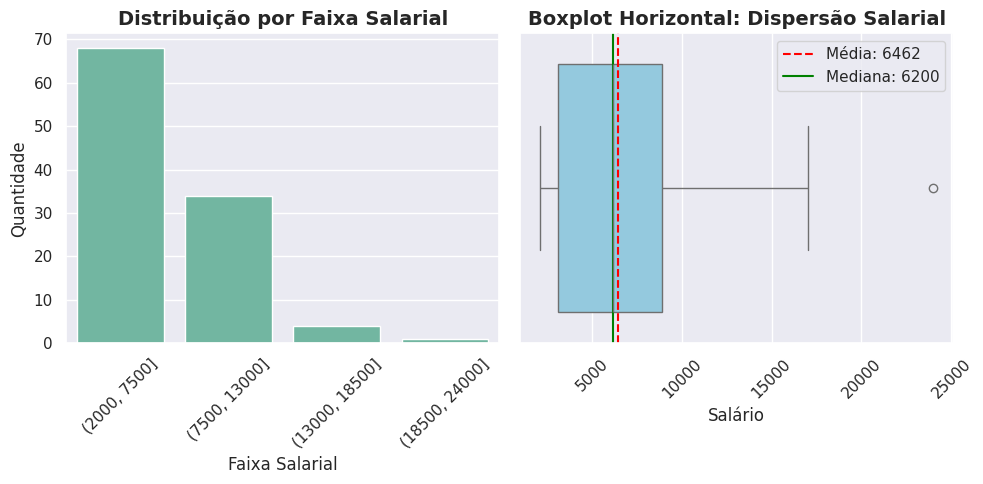

In [627]:

#############################################################    
# AED -> Estatísticas para SALARIO
# Objetivo: Criar o gráfico para visualização dos dados estatísticos
#############################################################  

# tema geral
sns.set_theme(
    style="darkgrid",
    palette="Set2"
)

# pasta para salvar gráficos
pasta_graficos = "./images/"

#criar painel 1x2
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# --------------------------------------------------
# 1. Gráfico de Barras: Distribuição
# --------------------------------------------------

sns.barplot(
    x=df_salario_distribuicao.index.astype(str),
    y=df_salario_distribuicao.values,
    ax=axes[0],
)
axes[0].set_title('Distribuição por Faixa Salarial', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Faixa Salarial')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=45)

# --------------------------------------------------
# 2. Gráfico Boxplot: Salário
# --------------------------------------------------

sns.boxplot(
    x=df_final['SALARIO'],
    ax=axes[1],
    color='skyblue'
)
axes[1].set_title('Boxplot Horizontal: Dispersão Salarial', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45) 
axes[1].set_xlabel('Salário')

# Linhas de Média e Mediana
axes[1].axvline(df_final['SALARIO'].mean(), color='red', linestyle='--', label=f'Média: {df_final["SALARIO"].mean():.0f}')
axes[1].axvline(df_final['SALARIO'].median(), color='green', linestyle='-', label=f'Mediana: {df_final["SALARIO"].median():.0f}')
axes[1].legend()   

plt.tight_layout()
plt.savefig(pasta_graficos + '01_estatisticas.png', dpi=300, bbox_inches='tight')
plt.show()



**CONCLUSÃO:**

- Mediana (50% - 6200.00): Indica que 50% dos funcionários recebem até esse valor.

- Média (mean = 6461.83): A média é ligeiramente maior que a mediana o que mostra uma assimetria a direita, onde poucos salários muito altos (como o outlier máx em 24000) puxam a média para cima enquano que a maioria das pessoas (68) estão concentradas na faixa inferior ( < 7500).

- Desvio Padrão (std = 3909.58): O desvio padrão é alto onde confirma a grande dispersão da amostra.

- Mínimo e Máximo: O menor salário é 2100 e o maior 24000 o que evidencia uma faixa salarial ampla.

- Moda: O valor de salário mais frequente é de 2500 e isso corrobora com nossa classe modal (faixa com mais ocorrências) que ficou no bin de 2000 - 7500.




---

```
┌───────────────────────────────────────────────────────────────────────┐
│   5.2 -> Salários por departamento e cargo                            │
└───────────────────────────────────────────────────────────────────────┘
```

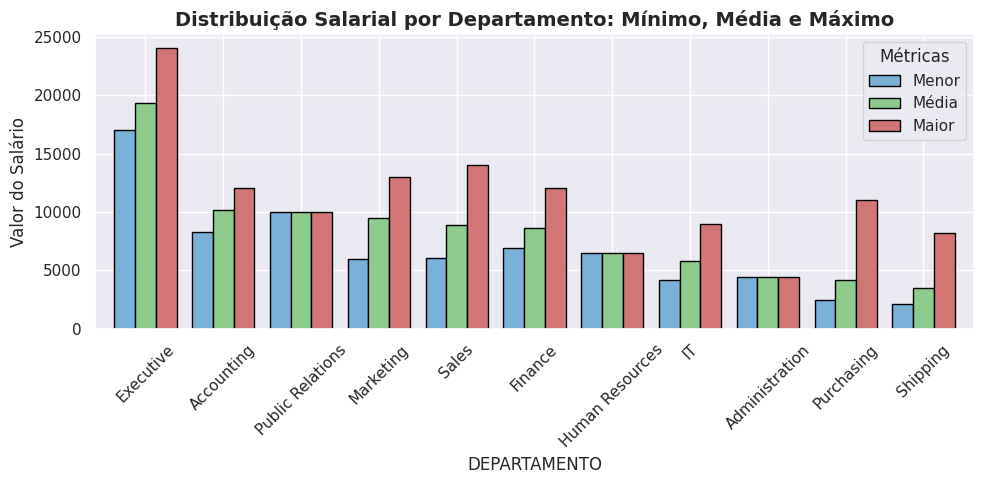

In [628]:

#############################################################    
# AED -> Analisar estatísticas dos salários por DEPARTAMENTO
#############################################################  

# usando método .agg() que calcula múltiplas métricas simultâneas
# 'observed=True' -> ignora categorias vazias

df_resumo_depto = df_final.groupby('DEPARTAMENTO', observed=True).agg(
    min_salarial=('SALARIO', 'min'),
    media_salarial=('SALARIO', 'mean'),
    max_salarial=('SALARIO', 'max')
).reset_index()

# Configurar o índice para ser o Departamento (para o eixo X)
df_plot = df_resumo_depto.sort_values("media_salarial", ascending=False).set_index('DEPARTAMENTO')

# Criar o gráfico
ax = df_plot.plot(
    kind='bar', 
    figsize=(10, 5), 
    color=["#7ab1d9", "#8dcc8d", "#d27676"], # Azul (Min), Vermelho (Max), Verde (Média)
    edgecolor='black',
    width=0.8
)

# Personalização
plt.title('Distribuição Salarial por Departamento: Mínimo, Média e Máximo', fontsize=14, fontweight='bold')
plt.xlabel('DEPARTAMENTO', fontsize=12)
plt.ylabel('Valor do Salário', fontsize=12)
plt.legend(title='Métricas', labels=['Menor', 'Média', 'Maior'])
plt.tick_params(axis='x', rotation=45) 

plt.tight_layout()
plt.savefig(pasta_graficos + '02_salarios_depto.png', dpi=300, bbox_inches='tight')
plt.show()   


**CONCLUSÃO:**

- O gráfico foi ordenado pela média salarial de cada departamento. Observa-se que o departamento "Executive" apresenta a maior média salarial, enquanto "Shipping" possui a menor.

- Em alguns departamentos, os salários mínimo e máximo estão relativamente próximos da média, indicando menor dispersão salarial. Já em departamentos como Shipping, Purchasing e Sales, a diferença entre os salários mínimo e máximo é maior, evidenciando maior variabilidade salarial dentro dessas áreas.

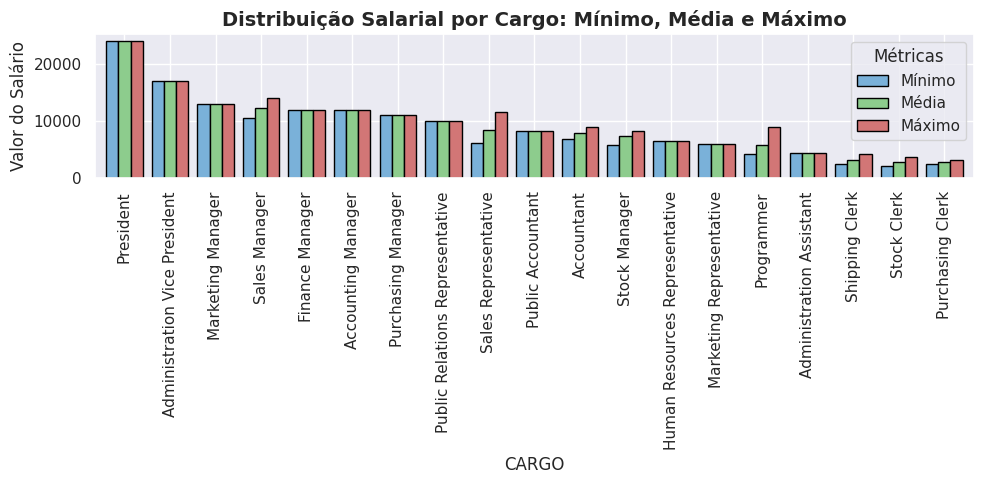

In [629]:

#############################################################    
# AED -> Analisar estatísticas dos salários por CARGO
#############################################################  

# usando método .agg() que calcula múltiplas métricas simultâneas
# 'observed=True' -> ignora categorias vazias

df_resumo_cargo = df_final.groupby('CARGO', observed=True).agg(
    min_salarial=('SALARIO', 'min'),
    media_salarial=('SALARIO', 'mean'),
    max_salarial=('SALARIO', 'max')
).reset_index()

# Configurar o índice para ser o Departamento (para o eixo X)
df_plot = df_resumo_cargo.sort_values("media_salarial", ascending=False).set_index('CARGO')

# Criar o gráfico
ax = df_plot.plot(
    kind='bar', 
    figsize=(10, 5), 
    color=["#7ab1d9", "#8dcc8d", "#d27676"], # Azul (Min), Vermelho (Max), Verde (Média)
    edgecolor='black',
    width=0.8
)

# Personalização
plt.title('Distribuição Salarial por Cargo: Mínimo, Média e Máximo', fontsize=14, fontweight='bold')
plt.xlabel('CARGO', fontsize=12)
plt.ylabel('Valor do Salário', fontsize=12)
plt.legend(title='Métricas', labels=['Mínimo', 'Média', 'Máximo'])

plt.tight_layout()
plt.savefig(pasta_graficos + '03_salarios_cargo.png', dpi=300, bbox_inches='tight')
plt.show()   


**CONCLUSÃO:**

- O gráfico foi ordenado pela média salarial dos cargos. Observa-se que President possui a maior média salarial, seguido por Administration Vice President, enquanto Purchansing Clerk apresenta a menor média salarial.

- Alguns cargos, como President, Accounting Manager, Finance Manager e Marketing Manager, apresentam salários mínimo, médio e máximo praticamente iguais, indicando uma remuneração padronizada para esses cargos ou a existência de apenas 1 funcionário neste cargo.

- Em contrapartida, cargos como Sales Manager, Sales Representative, Programmer e Accountant apresentam maior diferença entre os salários mínimo e máximo, evidenciando maior variabilidade salarial entre os ocupantes desses cargos.

---

```
┌───────────────────────────────────────────────────────────────────────┐
│   5.3 -> Funcionários por região (CIDADE)                             │
└───────────────────────────────────────────────────────────────────────┘
```

             CIDADE     ESTADO                                                 PAIS   REGIAO  QUANTIDADE
South San Francisco California                             United States of America Americas          45
             Oxford     Oxford United Kingdom of Great Britain and Northern Ireland   Europe          35
            Seattle Washington                             United States of America Americas          18
          Southlake      Texas                             United States of America Americas           5
            Toronto    Ontario                                               Canada Americas           2
             Munich    Bavaria                                              Germany   Europe           1
             London     London United Kingdom of Great Britain and Northern Ireland   Europe           1


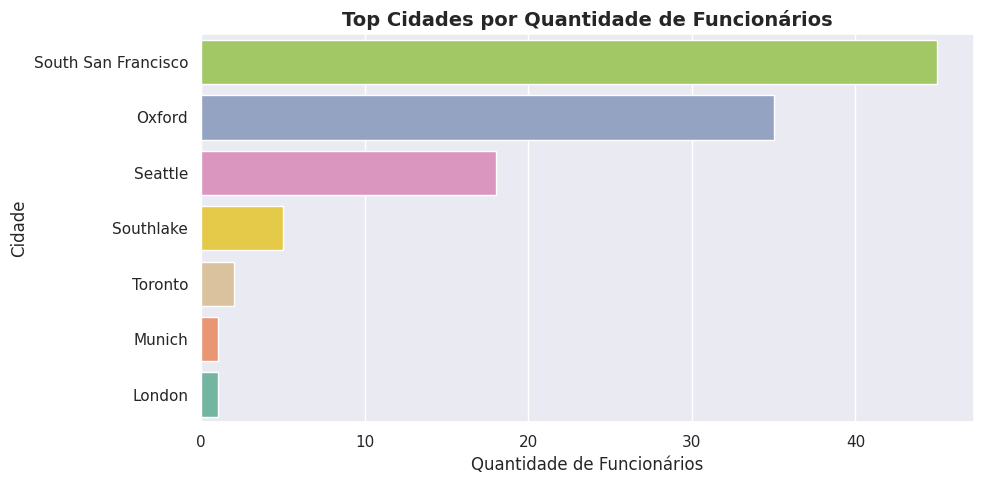

In [630]:
# Agrupar por cidade e recuperar as informações de localização + contagem
df_func_regiao = df_final.groupby('CIDADE', observed=True).agg(
    ESTADO=('ESTADO', 'first'),
    PAIS=('PAIS', 'first'),
    REGIAO=('REGIAO', 'first'),
    QUANTIDADE=('ID', 'count') 
).reset_index()

# Ordenar por quantidade (opcional, mas recomendado)
df_func_regiao = df_func_regiao.sort_values('QUANTIDADE', ascending=False)
ordem_barplot = df_func_regiao['CIDADE'].tolist()

print(df_func_regiao.to_string(index=False))   

plt.figure(figsize=(10, 5))

# Se houver muitas cidades, limite às top N para não ficar poluído (ex: top 15)
# Se forem poucas, use a tabela_resumo inteira

sns.barplot(
    data=df_func_regiao, 
    y='CIDADE', 
    x='QUANTIDADE', 
    hue='CIDADE',
    order=ordem_barplot,
)

plt.title('Top Cidades por Quantidade de Funcionários', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Funcionários')
plt.ylabel('Cidade')
plt.tight_layout()
plt.savefig(pasta_graficos + '04_funcionarios_cidade.png', dpi=300, bbox_inches='tight')
plt.show()   

**CONCLUSÃO:**

- A maioria dos funcionários estão na localidade de "South San Francisco" (California) com 45 funcionários, seguido por "Oxford" (Oxford) com 35 funcionarios e "Seattle" (Washington) com 18 funcionários.

- Interessante notar que as cidades de "Munich" (Bavaria) e "London" (London) possuem apenas 1 funcionário cada

---

```
┌───────────────────────────────────────────────────────────────────────┐
│   5.4 -> Salários por região (CIDADE)                                 │
└───────────────────────────────────────────────────────────────────────┘
```

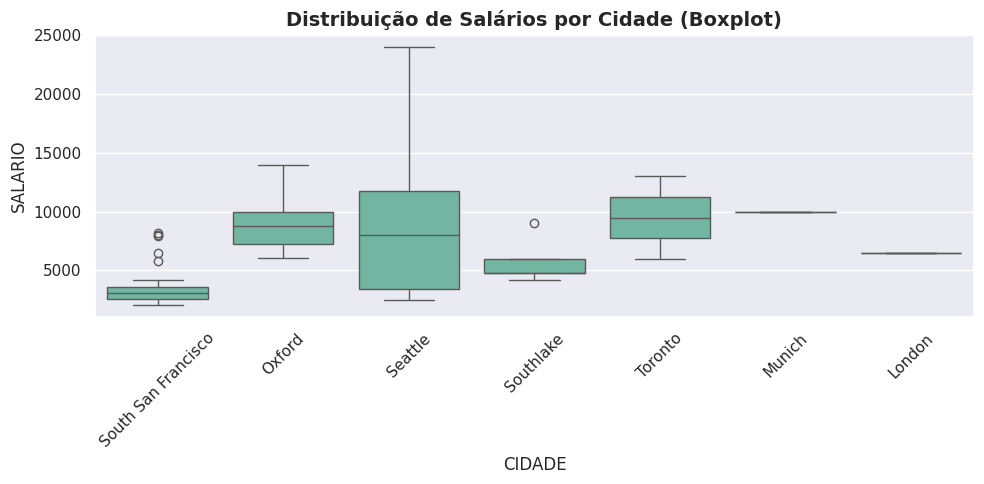

In [631]:
# Gráfico Boxplot: Salário por Cidade

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_final, 
    x='CIDADE', 
    y='SALARIO', 
    order=df_final['CIDADE'].value_counts().index
)

plt.title('Distribuição de Salários por Cidade (Boxplot)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(pasta_graficos + '05_salarios_cidade.png', dpi=300, bbox_inches='tight')
plt.show()   

**CONCLUSÃO:**

- Seattle apresenta a maior dispersão salarial, com salários variando aproximadamente entre R$ 2.500 e R$ 24.000.

- Toronto e Oxford possuem medianas salariais relativamente elevadas e menor dispersão que Seattle, sugerindo salários mais concentrados em torno da mediana.

- South San Francisco concentra os menores salários da amostra, embora apresente alguns outliers com remunerações significativamente superiores ao restante dos funcionários da cidade.

- Munich e London como possuem somente 1 funcionário faz com que não haja dispersão salarial.

---

```
┌───────────────────────────────────────────────────────────────────────┐
│   5.5 -> Ano / Mês com maiores contratações                           │
└───────────────────────────────────────────────────────────────────────┘
```

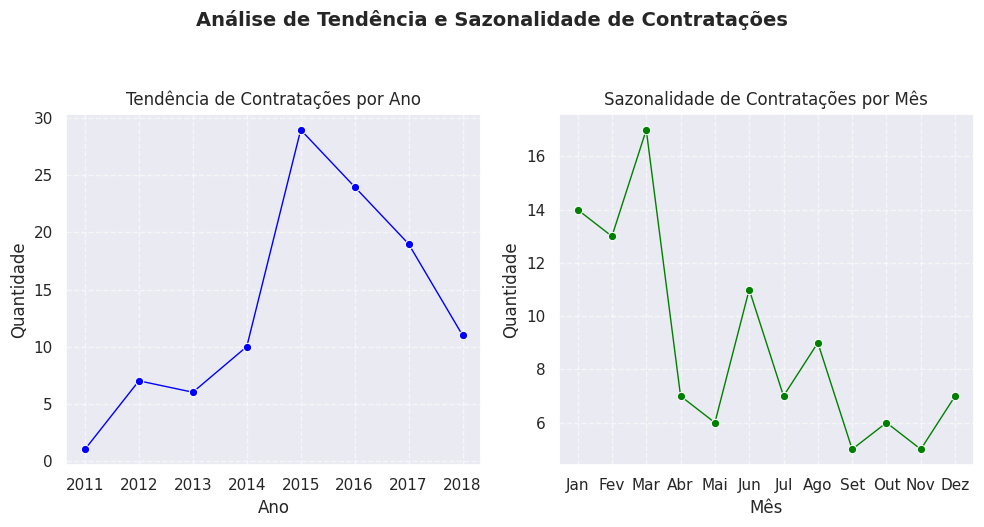

In [632]:
# Agrupar por Ano e Mês
df_ano = df_final.groupby('ANO').size().reset_index(name='QTD_CONTRATACOES').sort_values('ANO')
df_mes = df_final.groupby('MES').size().reset_index(name='QTD_CONTRATACOES').sort_values('MES')

# Mapear nomes dos meses para o eixo X
nome_meses = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
    7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}
df_mes['MES_NOME'] = df_mes['MES'].map(nome_meses)

# Criar Subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))


# --------------------------------------------------
# 1. Gráfico de Linha: Evolução por Ano
# --------------------------------------------------

# marker='o' adiciona bolinhas nos pontos para destacar o valor exato
sns.lineplot(
    data=df_ano, 
    x='ANO', 
    y='QTD_CONTRATACOES', 
    ax=axes[0], 
    marker='o', 
    linewidth=1, 
    color='blue'
)

axes[0].set_title('Tendência de Contratações por Ano', fontsize=12)
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Quantidade')
axes[0].grid(True, linestyle='--', alpha=0.6)

# --------------------------------------------------
# 2. Gráfico de Linha: Evolução por Mês
# --------------------------------------------------

# Uso da coluna "MES" para o eixo x e a coluna "MES_NOME" para o rótulo
sns.lineplot(
    data=df_mes, 
    x='MES', 
    y='QTD_CONTRATACOES', 
    ax=axes[1], 
    marker='o', 
    linewidth=1, 
    color='green'
)

axes[1].set_title('Sazonalidade de Contratações por Mês', fontsize=12)
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Quantidade')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Ajustar rótulos
axes[1].set_xticks(df_mes['MES'])
axes[1].set_xticklabels(df_mes['MES_NOME'])

plt.suptitle('Análise de Tendência e Sazonalidade de Contratações', fontsize=14, y=1.05, fontweight='bold')
plt.tight_layout()
plt.savefig(pasta_graficos + '06_sazonalidade_contratacao.png', dpi=300, bbox_inches='tight')
plt.show()   

**CONCLUSÃO:**

- Observa-se uma tendência de crescimento nas contratações entre 2011 e 2015, ano em que foi registrado o maior número de admissões. A partir de 2016, houve uma redução gradual no número de contratações, embora os valores permaneçam superiores aos observados no início da série.

- Em relação à sazonalidade, março foi o mês com maior número de contratações, enquanto setembro e novembro apresentaram os menores volumes. As contratações ocorreram ao longo de todo o ano, porém com maior concentração no primeiro trimestre, especialmente entre janeiro e março.

---

```
┌───────────────────────────────────────────────────────────────────────┐
│   5.6 -> Tempo de casa vs Salário para um mesmo Departamento          │
└───────────────────────────────────────────────────────────────────────┘
```

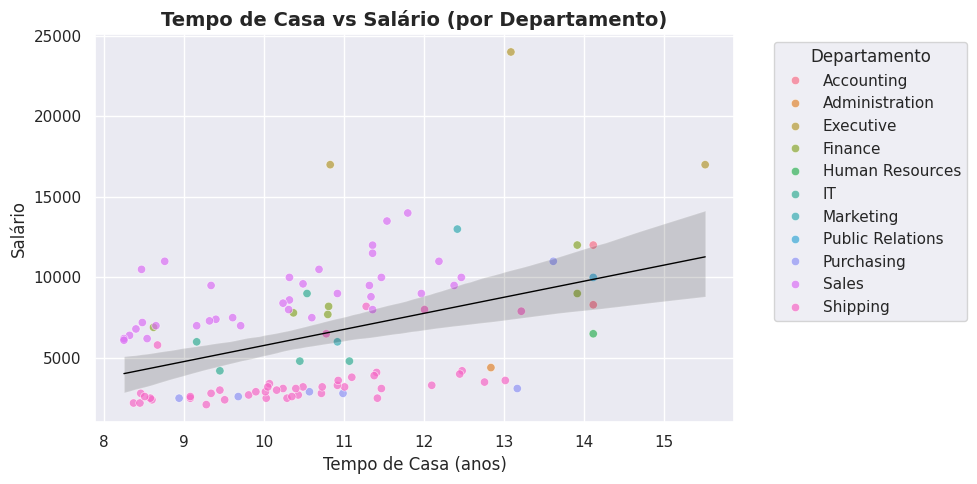

In [633]:
plt.figure(figsize=(10, 5))

# Gráfico de dispersão scatterplot com coloração por Departamento
sns.scatterplot(
    data=df_final,
    x="TEMPO_CASA",
    y="SALARIO",
    hue="DEPARTAMENTO",
    alpha=0.7
)

# Adicionar uma linha de tendência geral (linha regressão linear)
# Sombreado exibe o "Intervalo de Confiança"
sns.regplot(
    data=df_final,
    x="TEMPO_CASA",
    y="SALARIO",
    scatter=False,     
    color="black",     
    line_kws={"linewidth": 1}
)


plt.title('Tempo de Casa vs Salário (por Departamento)', fontsize=14, fontweight='bold')
plt.legend(title="Departamento", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xlabel('Tempo de Casa (anos)')
plt.ylabel('Salário')
plt.tight_layout()
plt.savefig(pasta_graficos + '07_tempocasa_salario.png', dpi=300, bbox_inches='tight')
plt.show()

**CONCLUSÃO:**

- A linha de regressão preta indica uma correlação linear positiva, ou seja, na média da empresa, quanto maior o tempo de casa, maior tende a ser o salário do funcionário.

- Embora a tendência geral seja de alta alguns departamentos tem comportamentos diferentes. 

Exemplos: 

Executive, apresenta os salários mais isolados e elevados do gráficos (outliers acima de 15000) mesmo sem tem o maior tempo de casa. Ainda podemos observar um funcionário com aproximadamente 13 anos de casa ganhando mais que outro com mais de 15 anos.

Sales e Finance, apresentam uma progressão salarial acima da média conforme o tempo passa.

Shipping e Purchasing, ficam concentrados na base do gráfico (abaixo de 5000), mostrando pouca variação salarial relevante com o aumento do tempo de casa.

- Dispersão e variabilidade: A área sombreada (intervalo de confiança) alarga-se nos anos finais (após 13 anos). Issso mostra que, para funcionários muito antigos, o salário se torna menos previsível apenas pelo tempo de casa, dependendo mais de fatores como o departamento em que ele trabalha.

